In [15]:
import numpy as np 
n_samples = 1000000 
p = 100 
low = 0 
high = 1 
length = 0.977237
lower_val = (1-length)/2 
upper_val = 1 - lower_val 
lower_bounds = np.full(shape=p,fill_value=lower_val) 
upper_bounds = np.full(shape=p,fill_value=upper_val) 
samples = np.random.uniform(low, high, size=(n_samples,p)) 
results = np.all((samples >= lower_bounds) & (samples <= upper_bounds), axis=1)
percentage = sum(results)/n_samples 
print(percentage)


0.100209


In [16]:
import numpy as np 
import pandas as pd 
import seaborn as sns; sns.set() 
import matplotlib.pyplot as plt 
import statsmodels.api as sm 
import statsmodels.formula.api as smf 
from ISLP import load_data 
from ISLP.models import ModelSpec as MS, summarize
from ISLP import confusion_table 
from ISLP.models import contrast 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA, QuadraticDiscriminantAnalysis as QDA
from sklearn.naive_bayes import GaussianNB 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression


In [17]:
from ISLP import load_data 
weekly = load_data('Weekly') 
weekly_df = pd.DataFrame(weekly) 
weekly_df.head() 
assert weekly_df.isnull().sum().sum() == 0 
weekly_df = pd.get_dummies(weekly_df).drop('Direction_Down', axis=1) 
weekly_df.head()


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction_Up
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,False
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,False
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,True
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,True
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,True


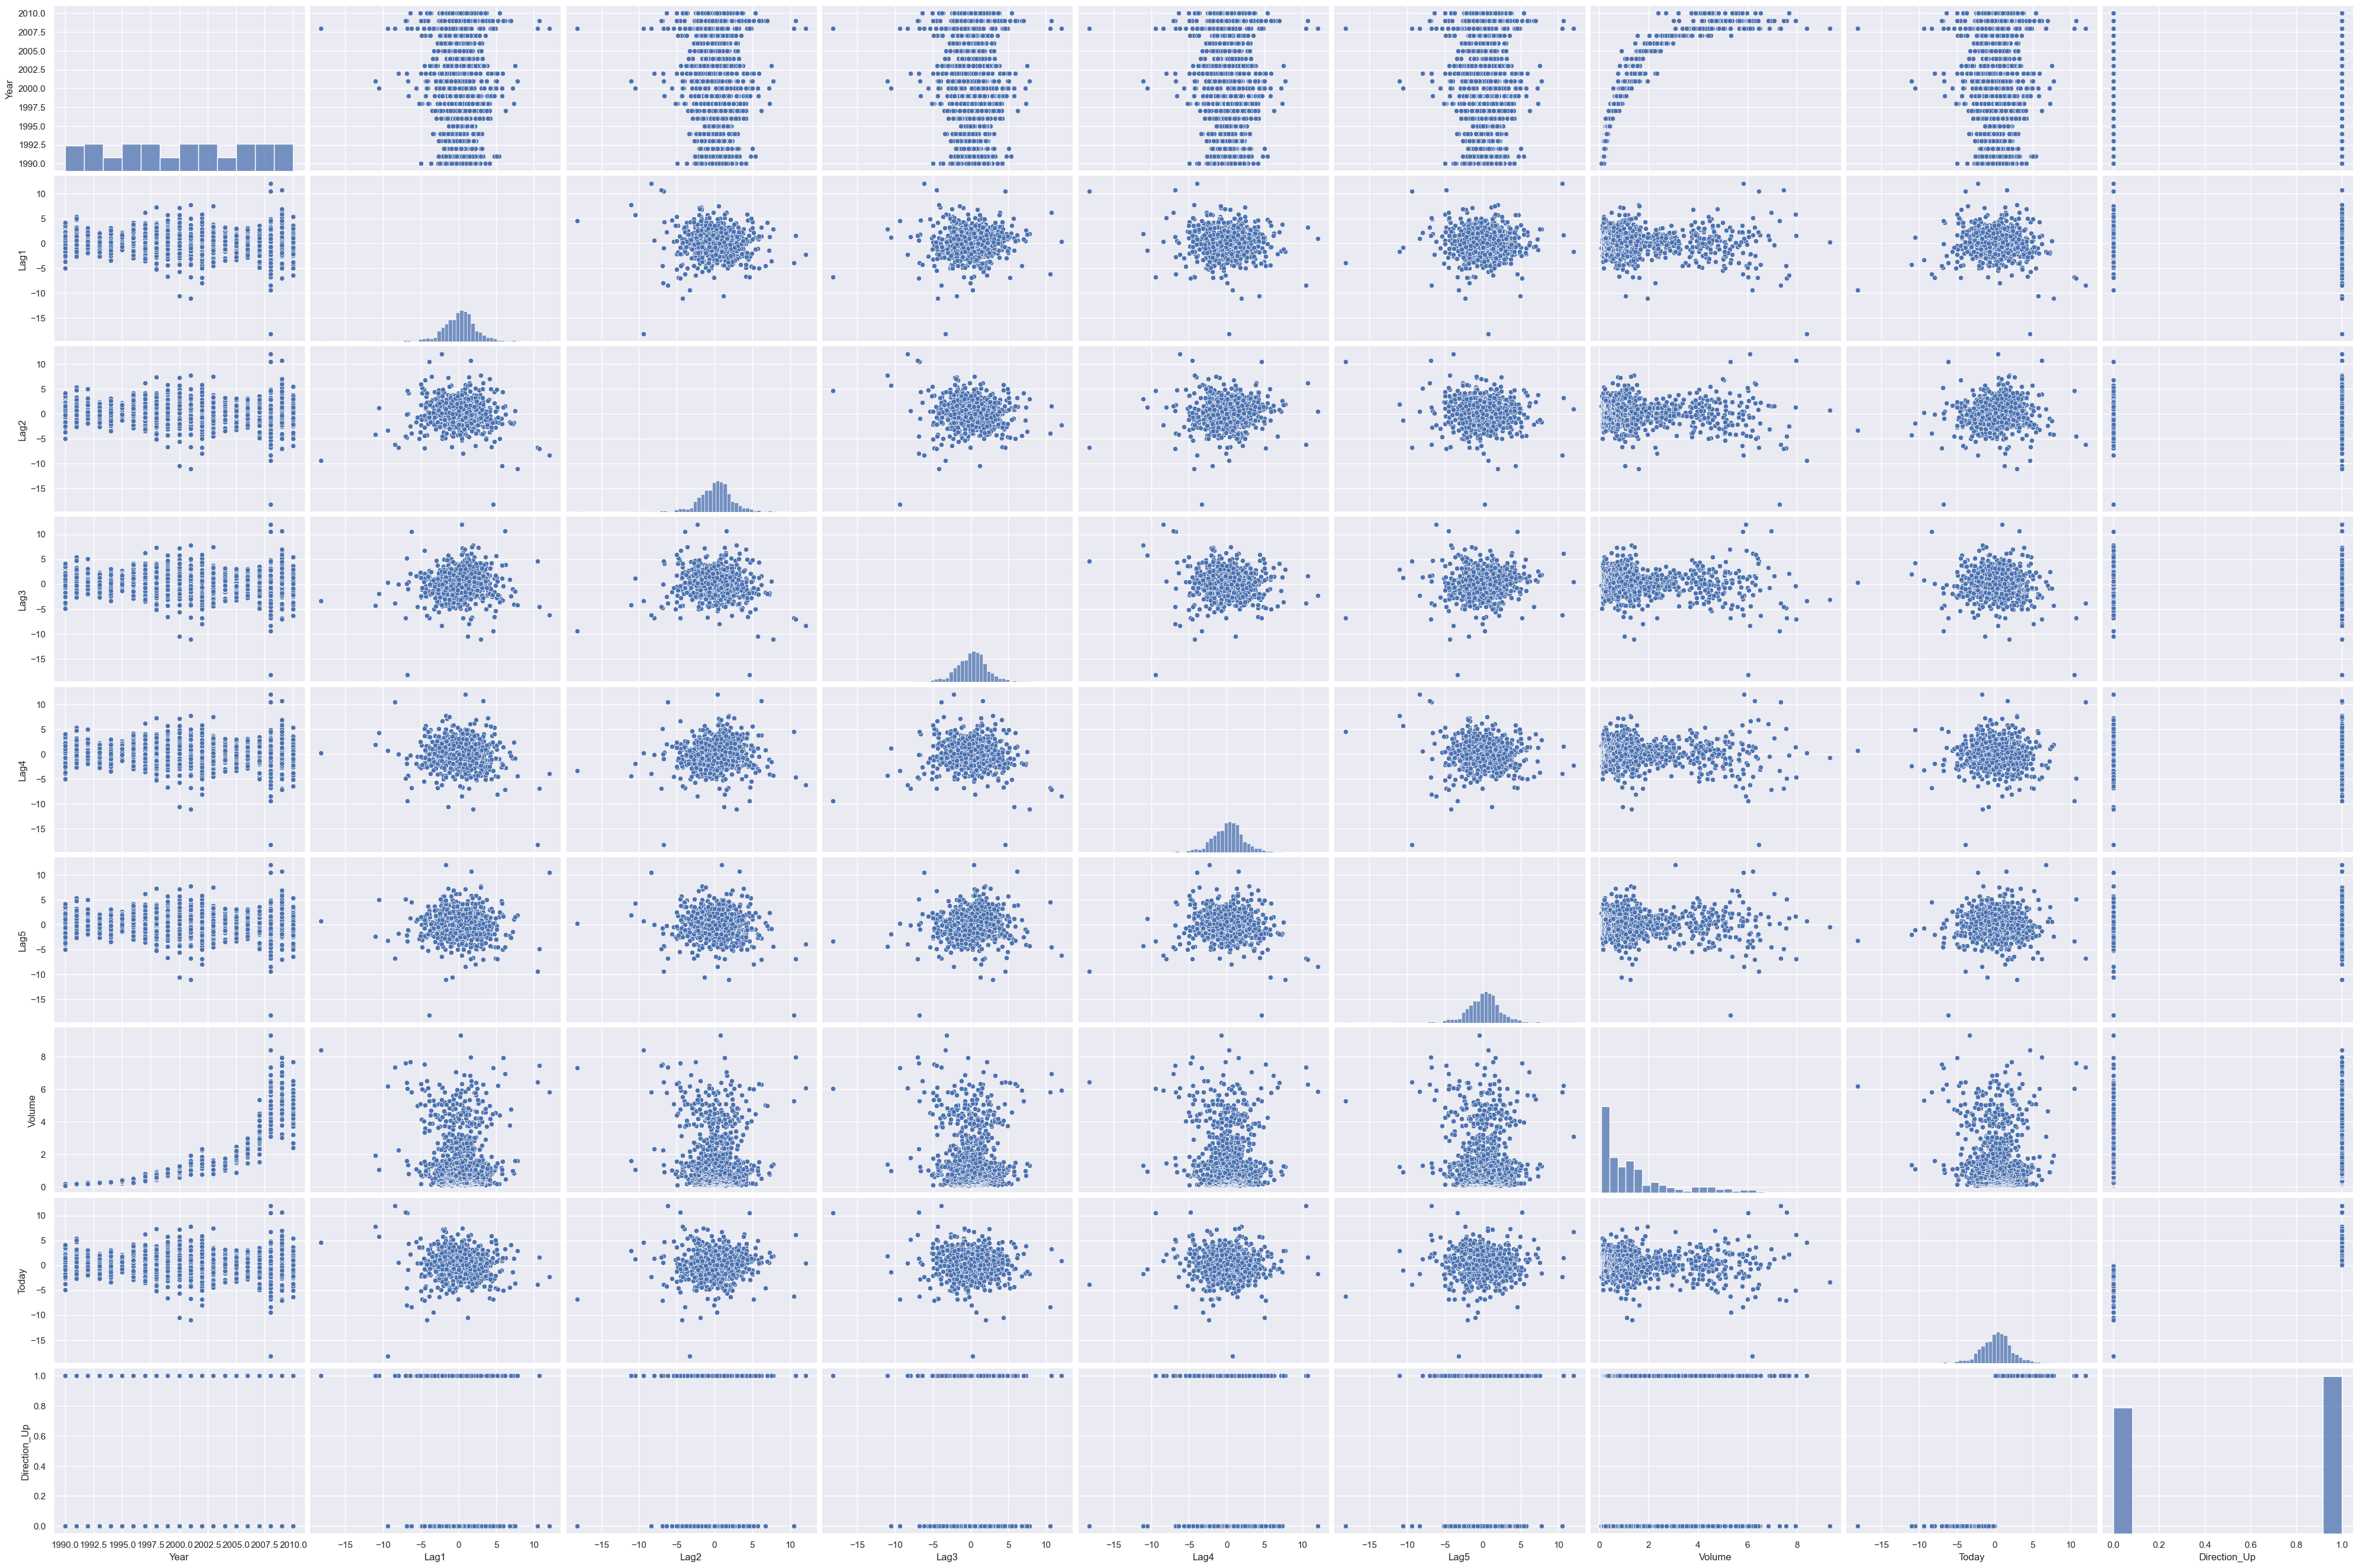

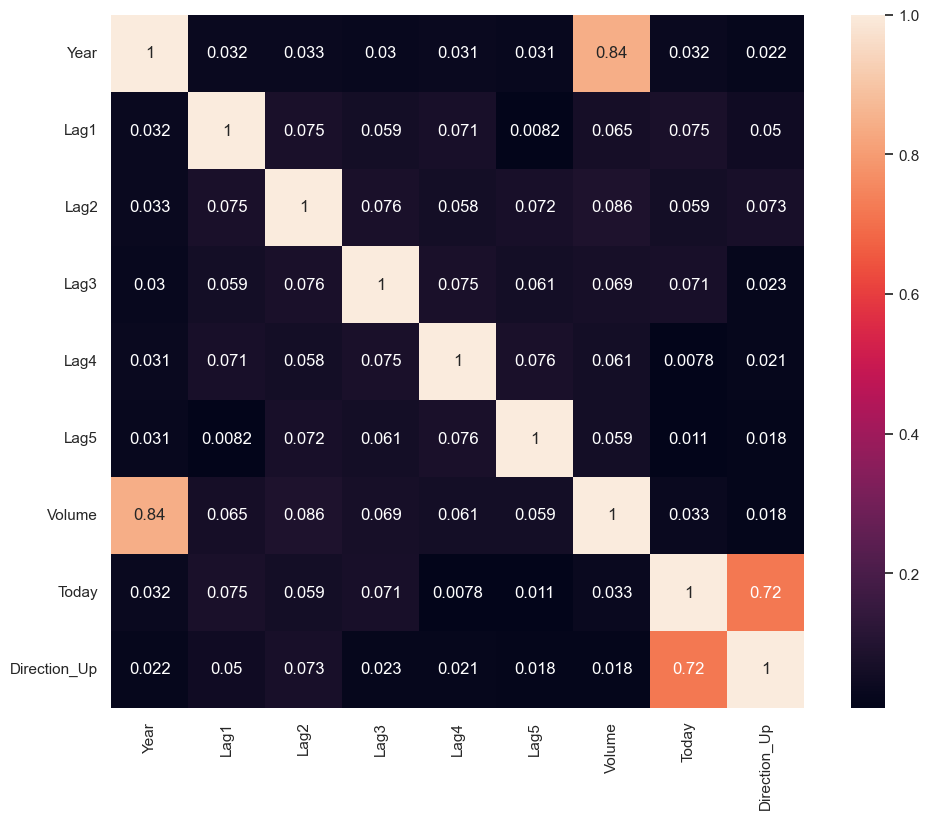

In [18]:
sns.pairplot(weekly_df,height=3, aspect=1.5) 
plt.show() 
corr_matrix = weekly_df.corr().abs() 
fig, ax = plt.subplots(figsize=(12, 9)) 
sns.heatmap(corr_matrix, vmax=1, square=True, annot=True) 
plt.xticks(rotation=90) 
plt.yticks(rotation=0);


In [19]:
allvars = weekly.columns.drop(['Today','Year','Direction']) 
design = MS(allvars) 
X = design.fit_transform(weekly) 
y = weekly.Direction == 'Up' 
glm = sm.GLM(y, X, family=sm.families.Binomial()) 
results = glm.fit() 
summarize(results)


,coef,std err,z,P>|z|
intercept,0.2669,0.086,3.106,0.002
Lag1,-0.0413,0.026,-1.563,0.118
Lag2,0.0584,0.027,2.175,0.030
Lag3,-0.0161,0.027,-0.602,0.547
Lag4,-0.0278,0.026,-1.050,0.294
Lag5,-0.0145,0.026,-0.549,0.583
Volume,-0.0227,0.037,-0.616,0.538


In [20]:
probs = results.predict() 
labels = np.array(['Down']*1089) 
labels[probs >0.5] = "Up" 
print(confusion_table(labels,weekly.Direction)) 
np.mean(labels == weekly.Direction)


Truth      Down   Up
Predicted           
Down         54   48
Up          430  557


np.float64(0.5610651974288338)

In [21]:
train = (weekly.Year < 2009) 
weekly_train = weekly.loc[train] 
weekly_test = weekly.loc[~train] 
weekly_test.shape 
allvars = weekly.columns.drop(['Today','Year','Direction','Lag1','Lag3','Lag4','Lag5','Volume'])
design = MS(allvars) 
X = design.fit_transform(weekly) 
X_train , X_test = X.loc[train], X.loc[~train] 
y_train , y_test = y.loc[train], y.loc[~train] 
glm_train = sm.GLM(y_train , 
X_train , 
family=sm.families.Binomial()) 
results = glm_train.fit() 
probs = results.predict(exog=X_test) 
D = weekly.Direction 
L_train , L_test = D.loc[train], D.loc[~train] 
labels = np.array(['Down']*104) 
labels[probs >0.5] = 'Up' 
print(confusion_table(labels , L_test))
np.mean(labels == L_test), np.mean(labels != L_test)


Truth      Down  Up
Predicted          
Down          9   5
Up           34  56


(np.float64(0.625), np.float64(0.375))

In [22]:
lda = LDA(store_covariance=True) 
X_train , X_test = [M.drop(columns=['intercept']) 
for M in [X_train , X_test]] 
lda.fit(X_train , L_train) 
lda_pred = lda.predict(X_test) 
print(confusion_table(lda_pred,L_test)) 
print("Accuracy:", float(np.mean(lda_pred == L_test)))


Truth      Down  Up
Predicted          
Down          9   5
Up           34  56
Accuracy: 0.625


In [23]:
qda = QDA(store_covariance=True) 
qda.fit(X_train , L_train) 
qda_pred = qda.predict(X_test) 
print(confusion_table(qda_pred , L_test))
print("Accuracy:", float(np.mean(qda_pred == L_test)))


Truth      Down  Up
Predicted          
Down          0   0
Up           43  61
Accuracy: 0.5865384615384616


In [24]:
NB = GaussianNB() 
NB.fit(X_train , L_train) 
nb_pred = NB.predict(X_test) 
print(confusion_table(nb_pred,L_test))
print("Accuracy:", float(np.mean(nb_pred == L_test)))


Truth      Down  Up
Predicted          
Down          0   0
Up           43  61
Accuracy: 0.5865384615384616


In [25]:
knn1 = KNeighborsClassifier(n_neighbors=1) 
knn1.fit(X_train , L_train) 
knn1_pred = knn1.predict(X_test) 
print(confusion_table(knn1_pred , L_test))
print("Accuracy:", float(np.mean(knn1_pred == L_test)))


Truth      Down  Up
Predicted          
Down         22  31
Up           21  30
Accuracy: 0.5
